In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('house_price_regression_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape: (1000, 8)

First few rows:
   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+05  
3            1                     8  2.296989e+05  
4            0                     8  1.041741e+06  

Data types:
Square_Footage            int64
Num_Bedrooms              int64
Num_Bathrooms             int64
Year_Built                int64
Lot_Size                float64
Garage_Size               int64
Ne

In [4]:
print("Data Preprocessing")

print("Checking for missing values")
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Missing values by column:\n{df.isnull().sum()}")

#print("No missing values found. Skipping imputation.")

print("Checking categorical variables")
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns: {list(categorical_cols)}")

print("Unique values in each column:")
for col in df.columns:
    unique_vals = df[col].nunique()
    print(f"{col}: {unique_vals} unique values")
    
#print("Identifying potential categorical variables")

print("Normalizing numerical features")
from sklearn.preprocessing import StandardScaler

X = df.drop('House_Price', axis=1)
y = df['House_Price']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Features have been standardized")

Data Preprocessing
Checking for missing values
Total missing values: 0
Missing values by column:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64
Checking categorical variables
Categorical columns: []
Unique values in each column:
Square_Footage: 894 unique values
Num_Bedrooms: 5 unique values
Num_Bathrooms: 3 unique values
Year_Built: 73 unique values
Lot_Size: 1000 unique values
Garage_Size: 3 unique values
Neighborhood_Quality: 10 unique values
House_Price: 1000 unique values
Normalizing numerical features
Features have been standardized


EDA


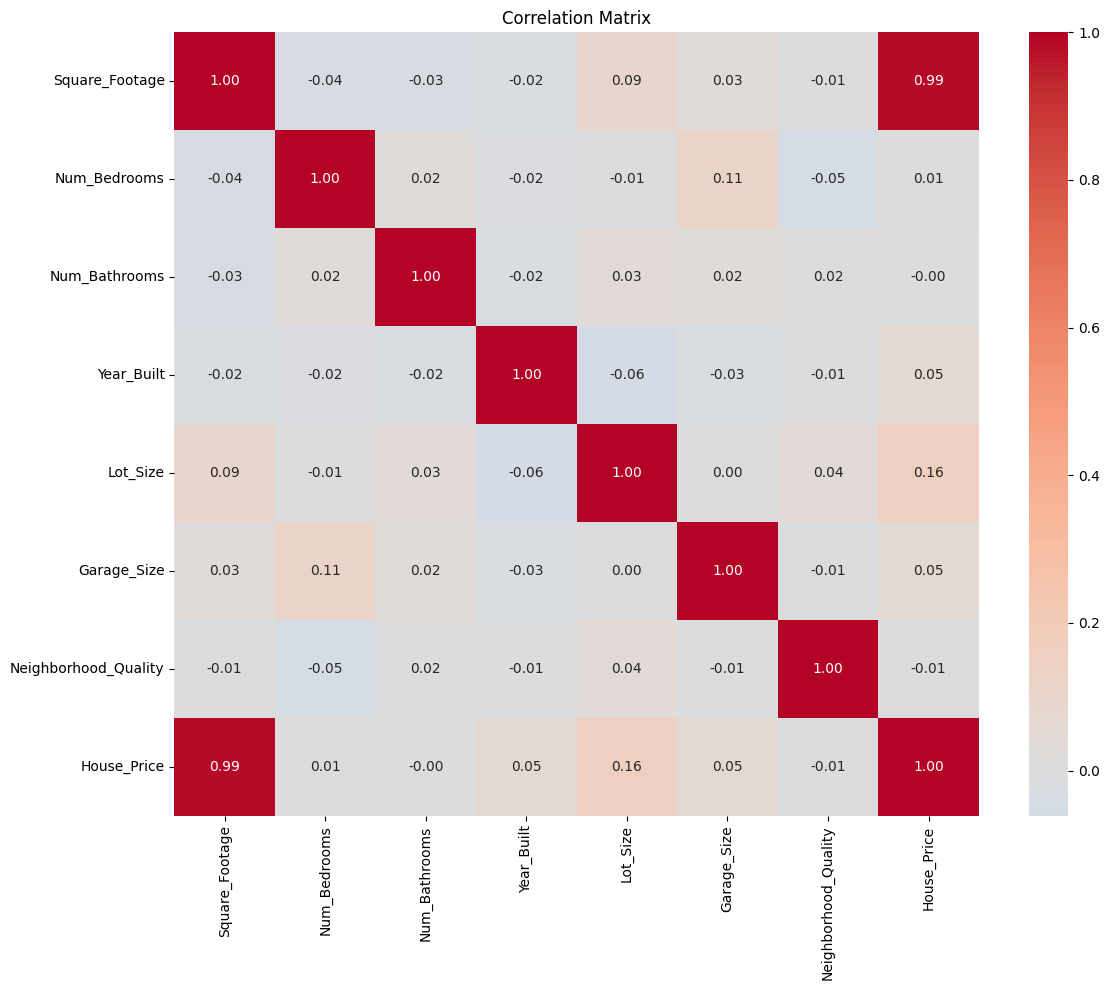

Correlations with House_Price:
House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64


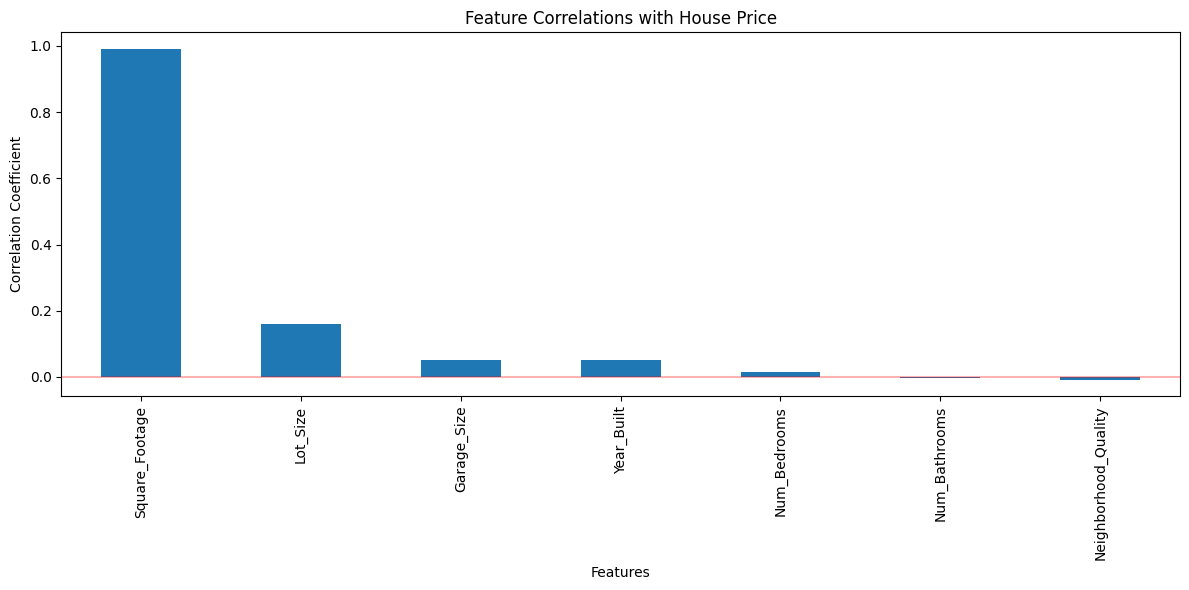

Calculating Variance Inflation Factor (VIF)
VIF values:
                Feature       VIF
1          Num_Bedrooms  1.018403
5           Garage_Size  1.015530
4              Lot_Size  1.014446
0        Square_Footage  1.012926
3            Year_Built  1.005280
6  Neighborhood_Quality  1.004384
2         Num_Bathrooms  1.004108
Top 15 most relevant features
Top 15 selected features based on correlation with target:
 1. Square_Footage: 0.9913
 2. Lot_Size: 0.1604
 3. Garage_Size: 0.0521
 4. Year_Built: 0.0520
 5. Num_Bedrooms: 0.0146
 6. Neighborhood_Quality: -0.0078
 7. Num_Bathrooms: -0.0019


In [9]:
print("EDA")

plt.figure(figsize=(12, 10))
correlation_matrix = pd.concat([X_scaled, y], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print("Correlations with House_Price:")
correlations_with_target = correlation_matrix['House_Price'].sort_values(ascending=False)
print(correlations_with_target)

plt.figure(figsize=(12, 6))
correlations_with_target.drop('House_Price').plot(kind='bar')
plt.title('Feature Correlations with House Price')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

print("Calculating Variance Inflation Factor (VIF)")
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled.values, i) 
                   for i in range(len(X_scaled.columns))]

print("VIF values:")
print(vif_data.sort_values('VIF', ascending=False))

print("Top 15 most relevant features")
top_features = correlations_with_target.drop('House_Price').abs().sort_values(ascending=False).head(15)
selected_features = top_features.index.tolist()

print(f"Top 15 selected features based on correlation with target:")
for i, feat in enumerate(selected_features, 1):
    corr = correlations_with_target[feat]
    print(f"{i:2}. {feat}: {corr:.4f}")

X_selected = X_scaled[selected_features]

In [12]:
print("Model Building")

from sklearn.model_selection import train_test_split

print("Splitting data")

X_temp, X_test, y_temp, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

print("Implementing Linear Regression")

class CustomLinearRegression:
    def __init__(self, add_intercept=True):
        self.add_intercept = add_intercept
        self.coefficients = None
        self.intercept = None
    
    def fit(self, X, y):
        if self.add_intercept:
            X = np.c_[np.ones(X.shape[0]), X]
        
        X_transpose = X.T
        X_transpose_X = np.dot(X_transpose, X)
        X_transpose_X_inv = np.linalg.inv(X_transpose_X)
        X_transpose_y = np.dot(X_transpose, y)
        
        beta = np.dot(X_transpose_X_inv, X_transpose_y)
        
        if self.add_intercept:
            self.intercept = beta[0]
            self.coefficients = beta[1:]
        else:
            self.intercept = 0
            self.coefficients = beta
        
        return self
    
    def predict(self, X):
        if self.add_intercept:
            return np.dot(X, self.coefficients) + self.intercept
        else:
            return np.dot(X, self.coefficients)
    
    def get_params(self):
        return {
            'intercept': self.intercept,
            'coefficients': self.coefficients
        }

print("Training linear regression model")
custom_model = CustomLinearRegression()
custom_model.fit(X_train.values, y_train.values)

print("Training sklearn LinearRegression model...")
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)

Model Building
Splitting data
Training set: (600, 7)
Validation set: (200, 7)
Test set: (200, 7)
\Implementing Linear Regression
Training linear regression model
Training sklearn LinearRegression model...


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
print("Comparing coefficients:")
print("\nCustom Model:")
print(f"Intercept: {custom_model.intercept:.6f}")
print("Coefficients:")
for i, (feature, coef) in enumerate(zip(selected_features, custom_model.coefficients), 1):
    print(f"  {feature}: {coef:.6f}")

print("\nSklearn Model:")
print(f"Intercept: {sklearn_model.intercept_:.6f}")
print("Coefficients:")
for i, (feature, coef) in enumerate(zip(selected_features, sklearn_model.coef_), 1):
    print(f"  {feature}: {coef:.6f}")

Comparing coefficients:

Custom Model:
Intercept: 618788.184032
Coefficients:
  Square_Footage: 250692.836790
  Lot_Size: 19485.140157
  Garage_Size: 4196.895446
  Year_Built: 20469.903844
  Num_Bedrooms: 14389.306185
  Neighborhood_Quality: 330.328128
  Num_Bathrooms: 6972.087110

Sklearn Model:
Intercept: 618788.184032
Coefficients:
  Square_Footage: 250692.836790
  Lot_Size: 19485.140157
  Garage_Size: 4196.895446
  Year_Built: 20469.903844
  Num_Bedrooms: 14389.306185
  Neighborhood_Quality: 330.328128
  Num_Bathrooms: 6972.087110


In [15]:
print("Model Evaluation")

def evaluate_model(model, X, y, model_name="Model", is_custom=True):
    if is_custom:
        predictions = model.predict(X.values)
    else:
        predictions = model.predict(X)
    
    mse = np.mean((y - predictions) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y - predictions))
    r2 = 1 - np.sum((y - predictions) ** 2) / np.sum((y - np.mean(y)) ** 2)
    
    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'Predictions': predictions
    }

print("Evaluation on Validation Set:")
val_results_custom = evaluate_model(custom_model, X_val, y_val, "Custom Model", is_custom=True)
val_results_sklearn = evaluate_model(sklearn_model, X_val, y_val, "Sklearn Model", is_custom=False)

results_df = pd.DataFrame([val_results_custom, val_results_sklearn])
results_df = results_df[['Model', 'RMSE', 'MAE', 'R²']]
print("\nValidation Results:")
print(results_df.to_string(index=False))

print("Evaluation on Test Set:")
test_results_custom = evaluate_model(custom_model, X_test, y_test, "Custom Model", is_custom=True)
test_results_sklearn = evaluate_model(sklearn_model, X_test, y_test, "Sklearn Model", is_custom=False)

test_results_df = pd.DataFrame([test_results_custom, test_results_sklearn])
test_results_df = test_results_df[['Model', 'RMSE', 'MAE', 'R²']]
print("\nTest Results:")
print(test_results_df.to_string(index=False))


Model Evaluation
Evaluation on Validation Set:

Validation Results:
        Model        RMSE         MAE       R²
 Custom Model 9343.650638 7277.136227 0.998719
Sklearn Model 9343.650638 7277.136227 0.998719
Evaluation on Test Set:

Test Results:
        Model         RMSE         MAE       R²
 Custom Model 10015.412446 8096.366118 0.998444
Sklearn Model 10015.412446 8096.366118 0.998444


Visualizing predictions vs actual:


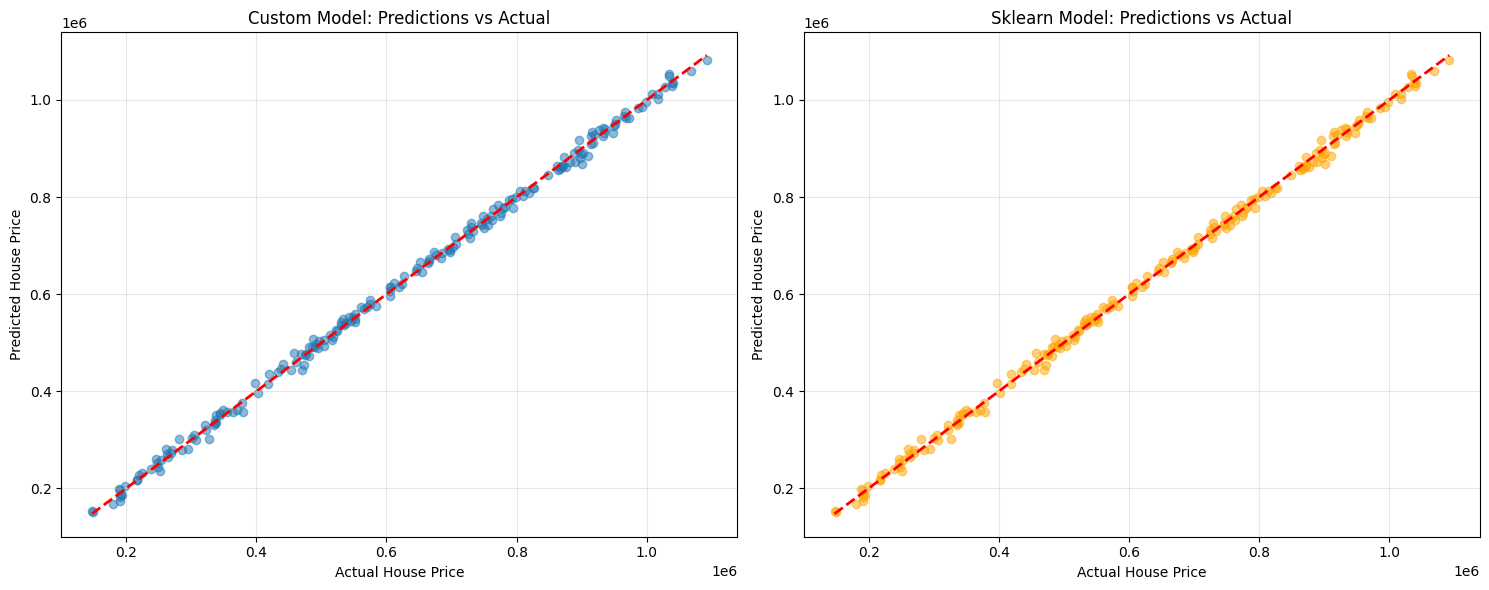

In [16]:
print("Visualizing predictions vs actual:")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Custom model
axes[0].scatter(y_test, test_results_custom['Predictions'], alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual House Price')
axes[0].set_ylabel('Predicted House Price')
axes[0].set_title('Custom Model: Predictions vs Actual')
axes[0].grid(True, alpha=0.3)

# Sklearn model
axes[1].scatter(y_test, test_results_sklearn['Predictions'], alpha=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual House Price')
axes[1].set_ylabel('Predicted House Price')
axes[1].set_title('Sklearn Model: Predictions vs Actual')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Visualizing residuals:


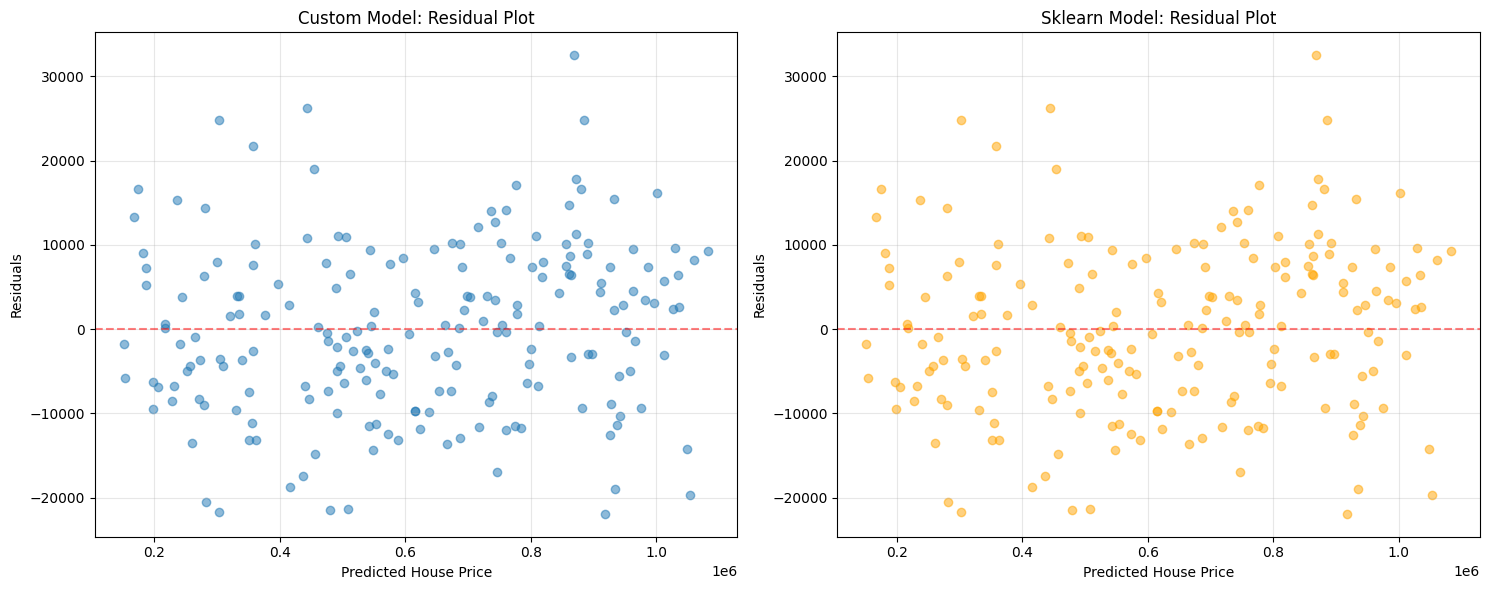

In [17]:
print("Visualizing residuals:")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Custom model
residuals_custom = y_test - test_results_custom['Predictions']
axes[0].scatter(test_results_custom['Predictions'], residuals_custom, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Predicted House Price')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Custom Model: Residual Plot')
axes[0].grid(True, alpha=0.3)

# Sklearn model
residuals_sklearn = y_test - test_results_sklearn['Predictions']
axes[1].scatter(test_results_sklearn['Predictions'], residuals_sklearn, alpha=0.5, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Predicted House Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Sklearn Model: Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()